# bilby `AGN-CBC_lensing` modifications and results

Summary of the gwfast→bilby lensing port, the AGN/generic/simple PE suite, Bayes factors.

## 1. bilby modifications

New submodule `bilby/gw/lensing/` (branch `AGN-CBC_lensing`), ported from gwfast AGN-CBC lensing:

| Piece | Role |
|---|---|
| `lensing_utils.py` | AGN disk lens geometry, time delay / magnification |
| `conversion.py` | bilby ↔ gwfast units; AGN→generic/simple image parameters |
| `source.py` | `agn_lensed_binary_black_hole`, `general_lensed_binary_black_hole` (dual-image FD sum, IMRPhenomD) |
| `priors.py` | `AGNLensedPriorDict`, `GenericLensedPriorDict`, `SimpleLensedPriorDict` |
| `inference.py` | injection helpers, segment window, PE runner, corner ordering |

Examples: `examples/gw_examples/lensing_examples/{agn,generic,simple}_pe.py`, `comparison.py`, and the fixed-binary `*_disk_pe.py` suite.

**Bayes factors** come from nested-sampling evidence, not the SDDR approximation anymore.


## 2. Shared injection

| Quantity | Value |
|---|---|
| Approximant | IMRPhenomD (aligned spin) |
| $\mathcal{M}$, $q$ | 30 $M_\odot$, 2/3 ($\eta=0.24$) |
| $d_L$ | 500 Mpc |
| $\chi_1$, $\chi_2$ | 0.3, 0.5 |
| $\iota$ | $0.99\times\pi/2$ (near edge-on) |
| $R_{\rm orbit}/R_S$, $\log_{10} M_{lz}$, $y_{\rm src}$ | 50, 5.0, 0.5 |
| Network SNR | ≈ 44.5 |
| Duration / $f_s$ | 32 s / 2048 Hz |
| True inter-image delay | ≈ **−11.96 s** |
| Distance ratio $d_{L,2}/d_{L,1}$ | ≈ 9.80 |
| Relative chirp mass | ≈ 1.037 |
| $\Delta\phi_{12}$ | ≈ 0.40 rad |

## 3. Priors

Shared CBC base: `AlignedSpinBBHPriorDict` → bilby `aligned_spins_bbh.prior`. Lensing extras from `bilby/gw/lensing/priors.py`. Examples set `geocent_time` via `set_example_pe_time_prior`.

### Shared BBH (all three models)

| Parameter | Prior | Range / notes |
|---|---|---|
| `mass_1`, `mass_2` | Constraint | $[5, 100]\,M_\odot$ |
| `chirp_mass` | `UniformInComponentsChirpMass` | $[25, 100]\,M_\odot$ |
| `mass_ratio` | `UniformInComponentsMassRatio` | $[0.125, 1]$ |
| `luminosity_distance` | `UniformSourceFrame` | $[100, 5000]$ Mpc |
| `dec` | Cosine | — |
| `ra` | Uniform (periodic) | $[0, 2\pi]$ |
| `theta_jn` | Sine | — |
| `psi` | Uniform (periodic) | $[0, \pi]$ |
| `phase` | Uniform (periodic) | $[0, 2\pi]$ |
| `chi_1`, `chi_2` | `AlignedSpin` (a$\sim$Uniform) | $a\in[0, 0.99]$ |
| `geocent_time` | Uniform (examples) | $t_{\rm inj}\pm 0.1$ s |

### Lensing parameters by model

| Parameter | AGN | Generic | Simple |
|---|---|---|---|
| `R_orbit` | LogUniform($10, 2000$) | — | — |
| `log10_M_lz` | Uniform($4, 7$) | — | — |
| `src_pos` | Uniform($-1, 1$) | — | — |
| `relative_mass` | — | Uniform($0.9, 1.1$) | fixed =1 |
| `relative_distance` | — | Uniform($0.1, 20$) | Uniform(0.1, 20) |
| `delta_iota` | — | Uniform($\pm 0.1$) | fixed =0 |
| `delta_phi_12` | — | Uniform($\pm\pi/4$) | fixed =0 |
| `delta_psi` | — | Uniform($\pm 0.1$) | fixed =0 |
| `delta_time` [s] | — | Uniform($\pm(T/2-1)$) $\approx \pm 15$ at $T$=32 s | same as generic |

**The newest runs still had the old wide priors for $\Delta\iota$ and $\Delta\psi$!**

In [2]:
from pathlib import Path
from IPython.display import Image, display, Markdown

ROOT = Path('..').resolve()
LENS = ROOT / 'outdir_lensing'
DISK = ROOT / 'outdir_disk'

def show(path, title=None, width=900):
    path = Path(path)
    if title:
        display(Markdown(f'**{title}**'))
    if not path.exists():
        display(Markdown(f'*Missing:* `{path}`'))
        return
    display(Image(filename=str(path), width=width))


## 4. Full (binary included) PE - with nlive=1000, $\Delta\ln Z$<0.1, duration=32s

### Corner plots

**AGN model (full PE)**

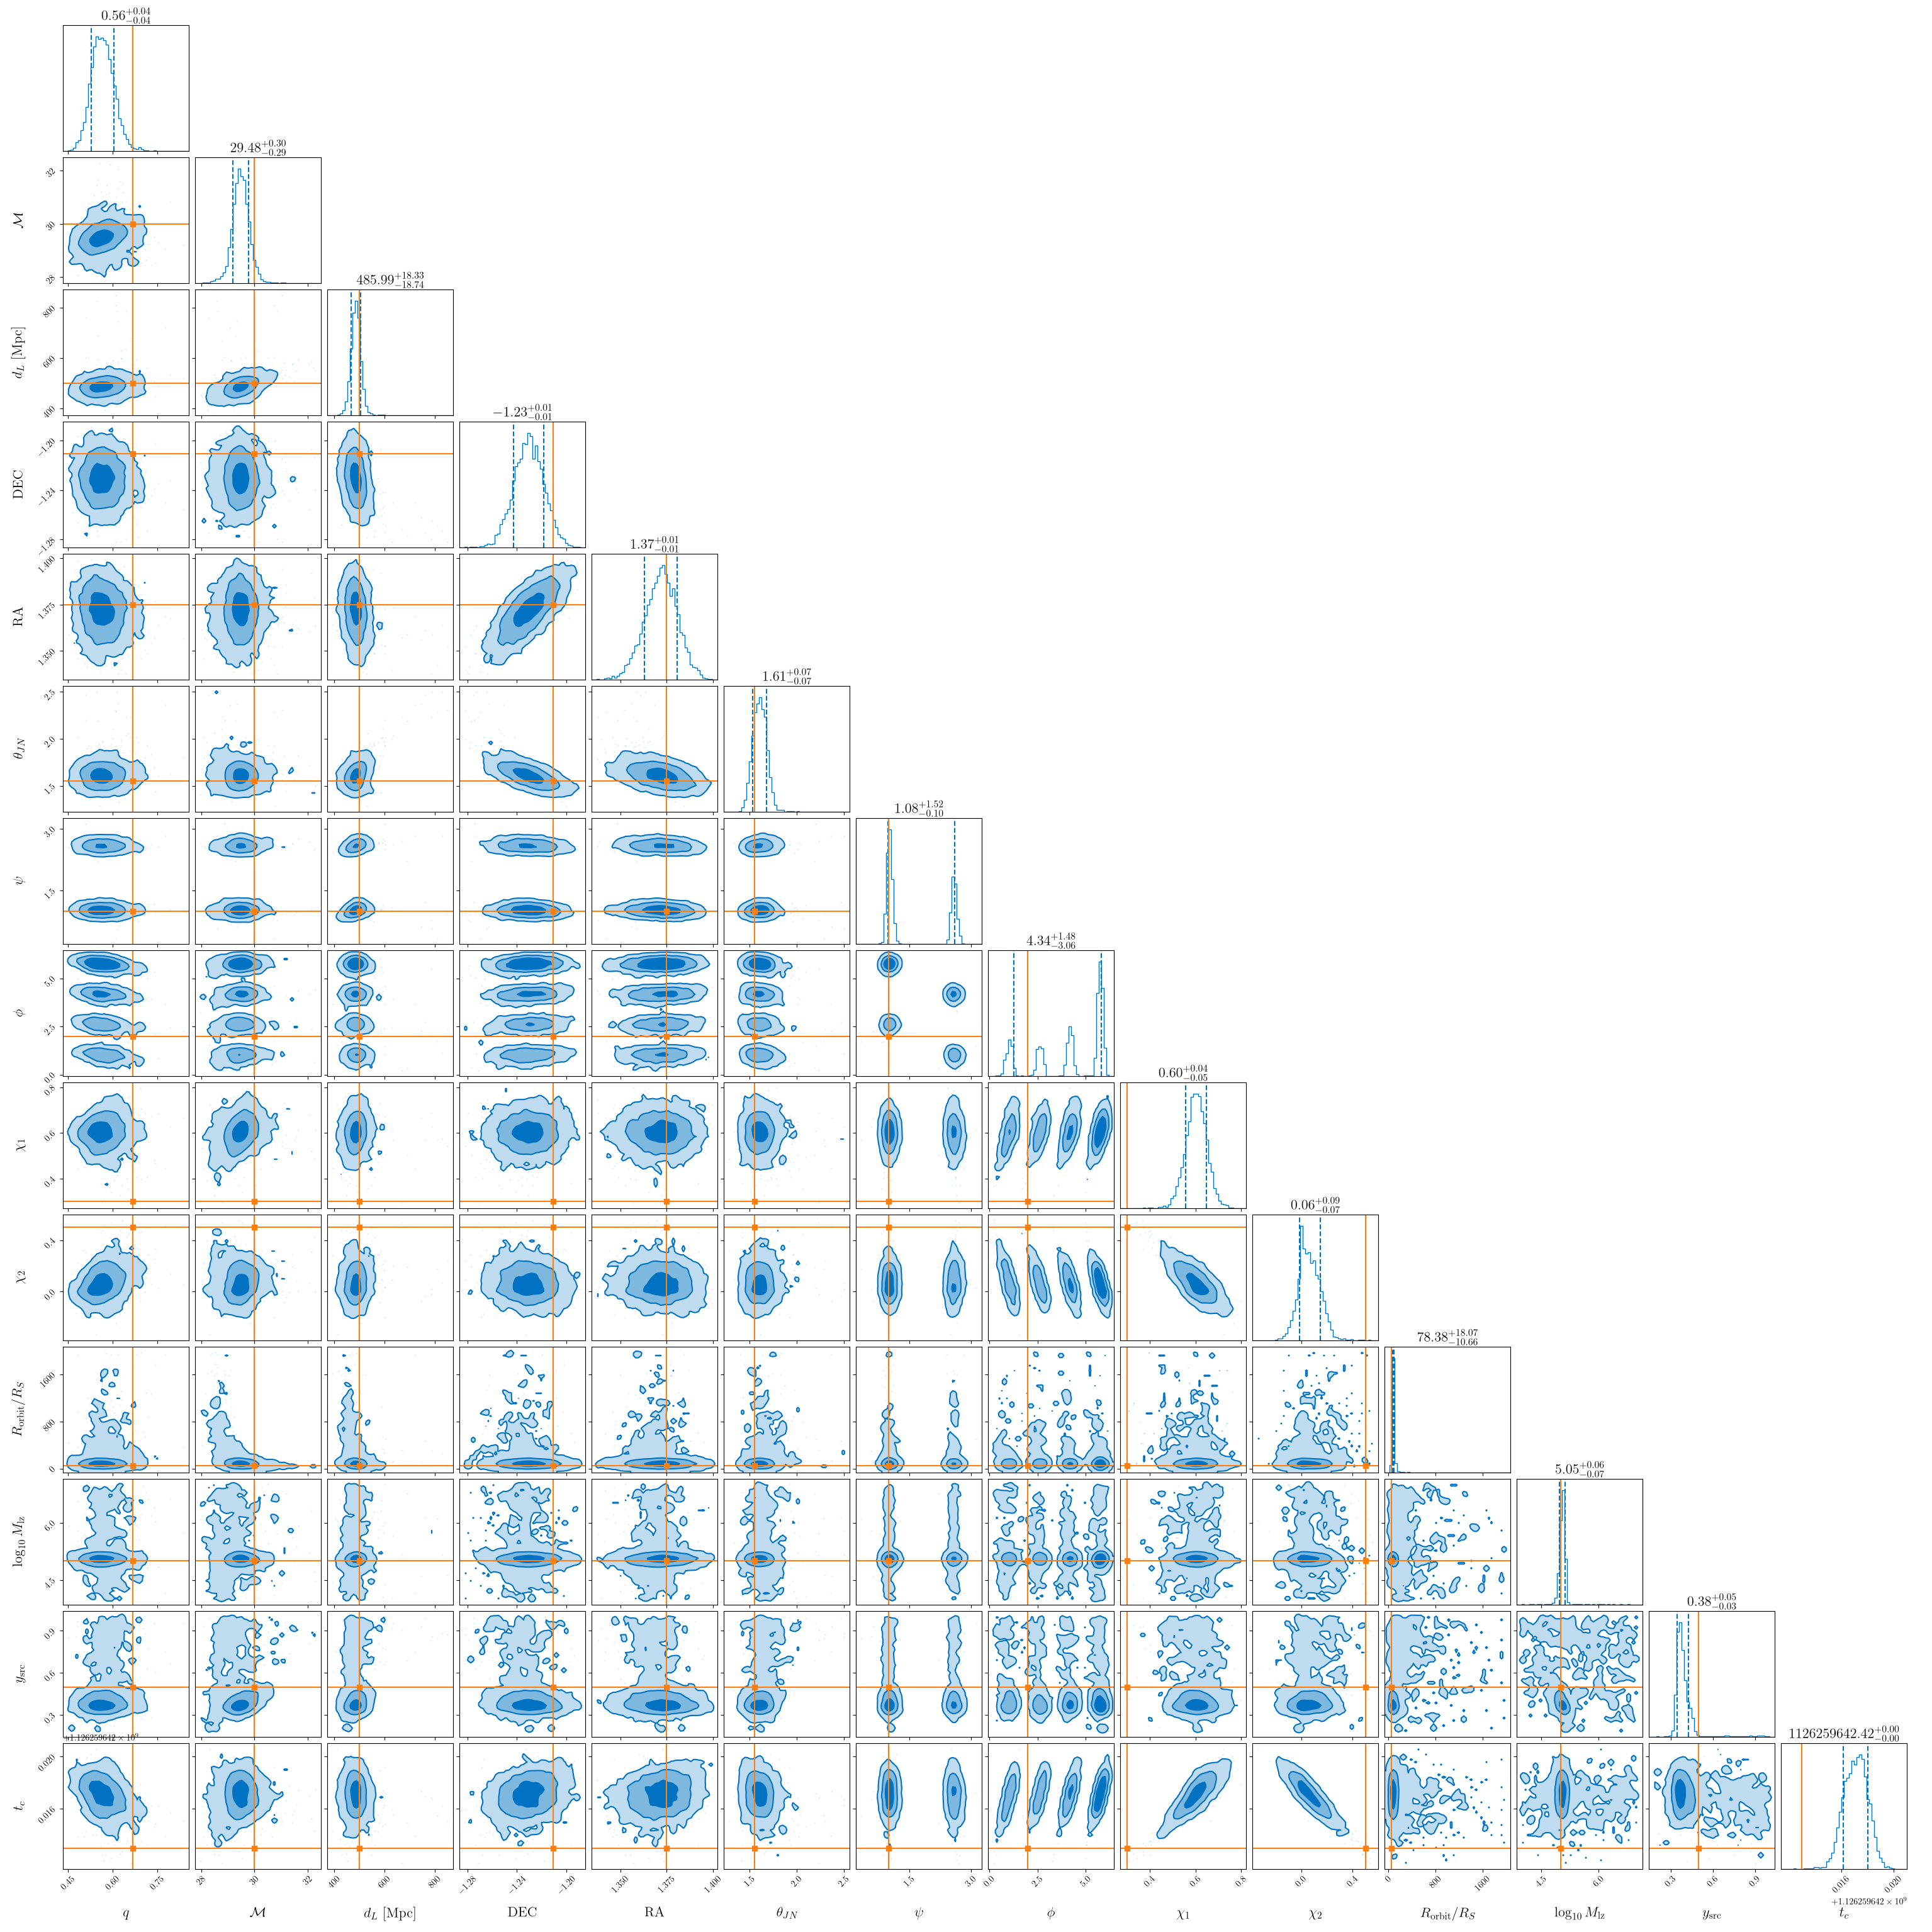

**Generic model (full PE)**

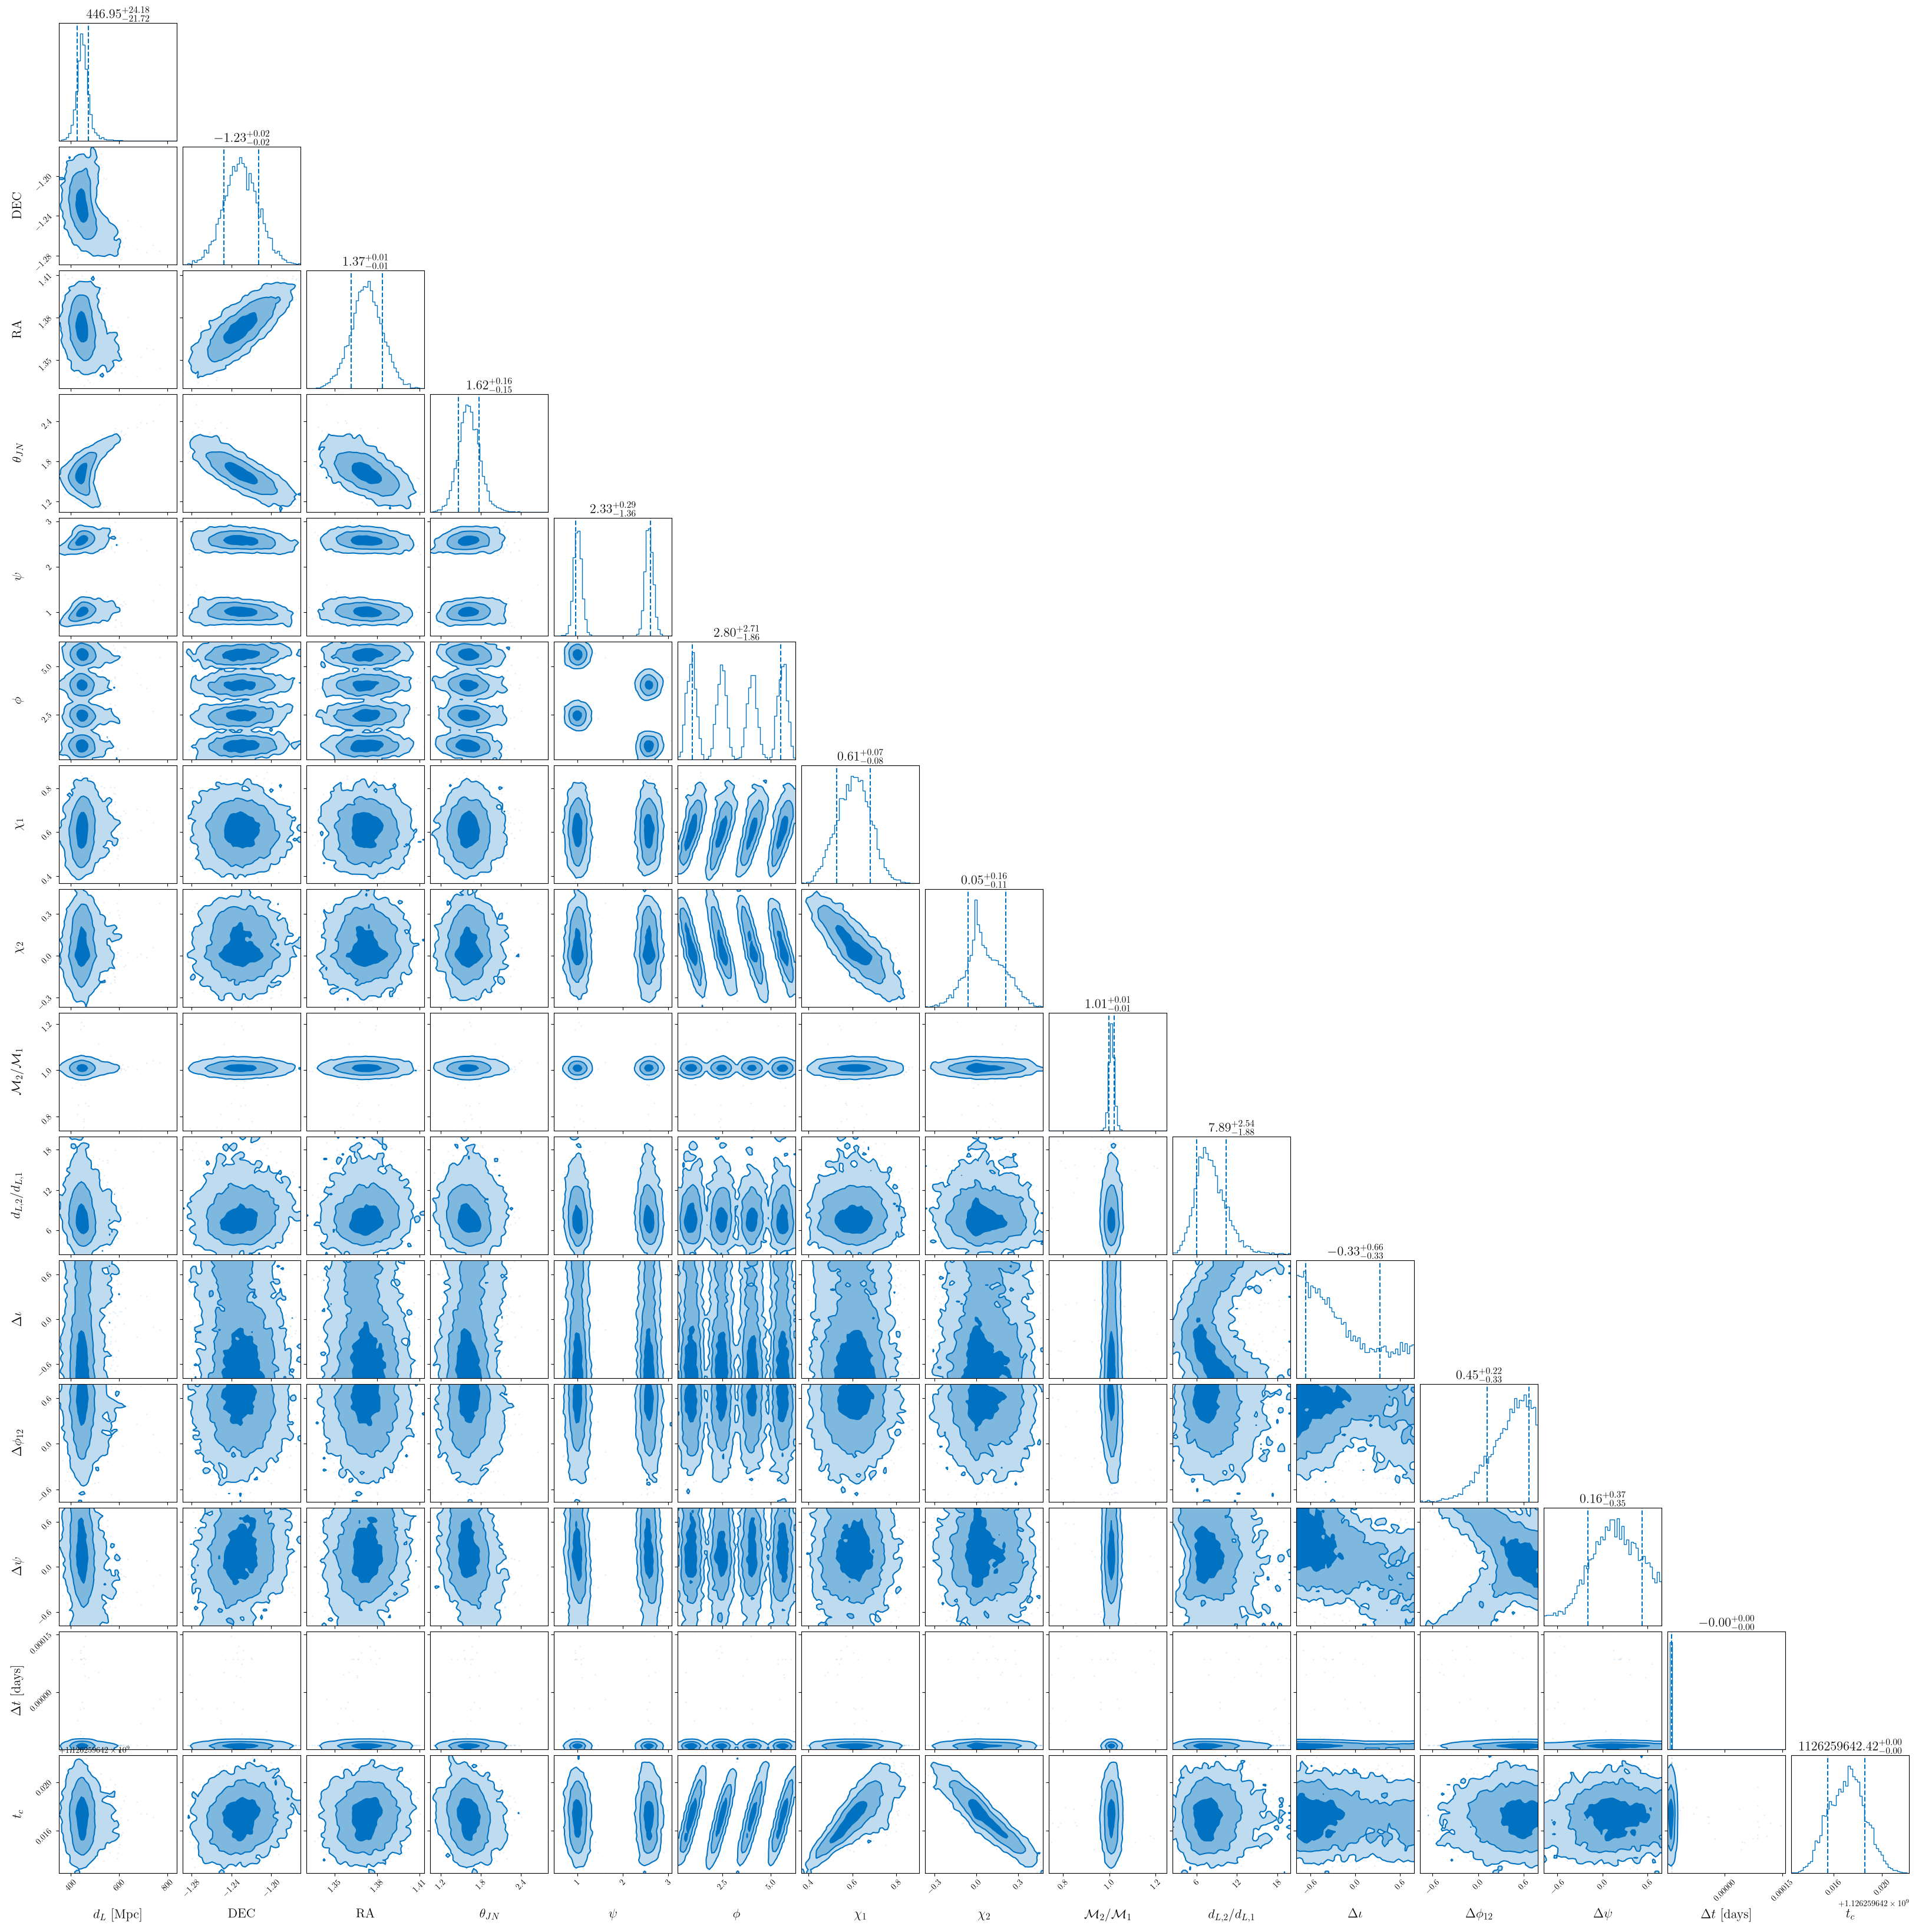

**Simple model (full PE)**

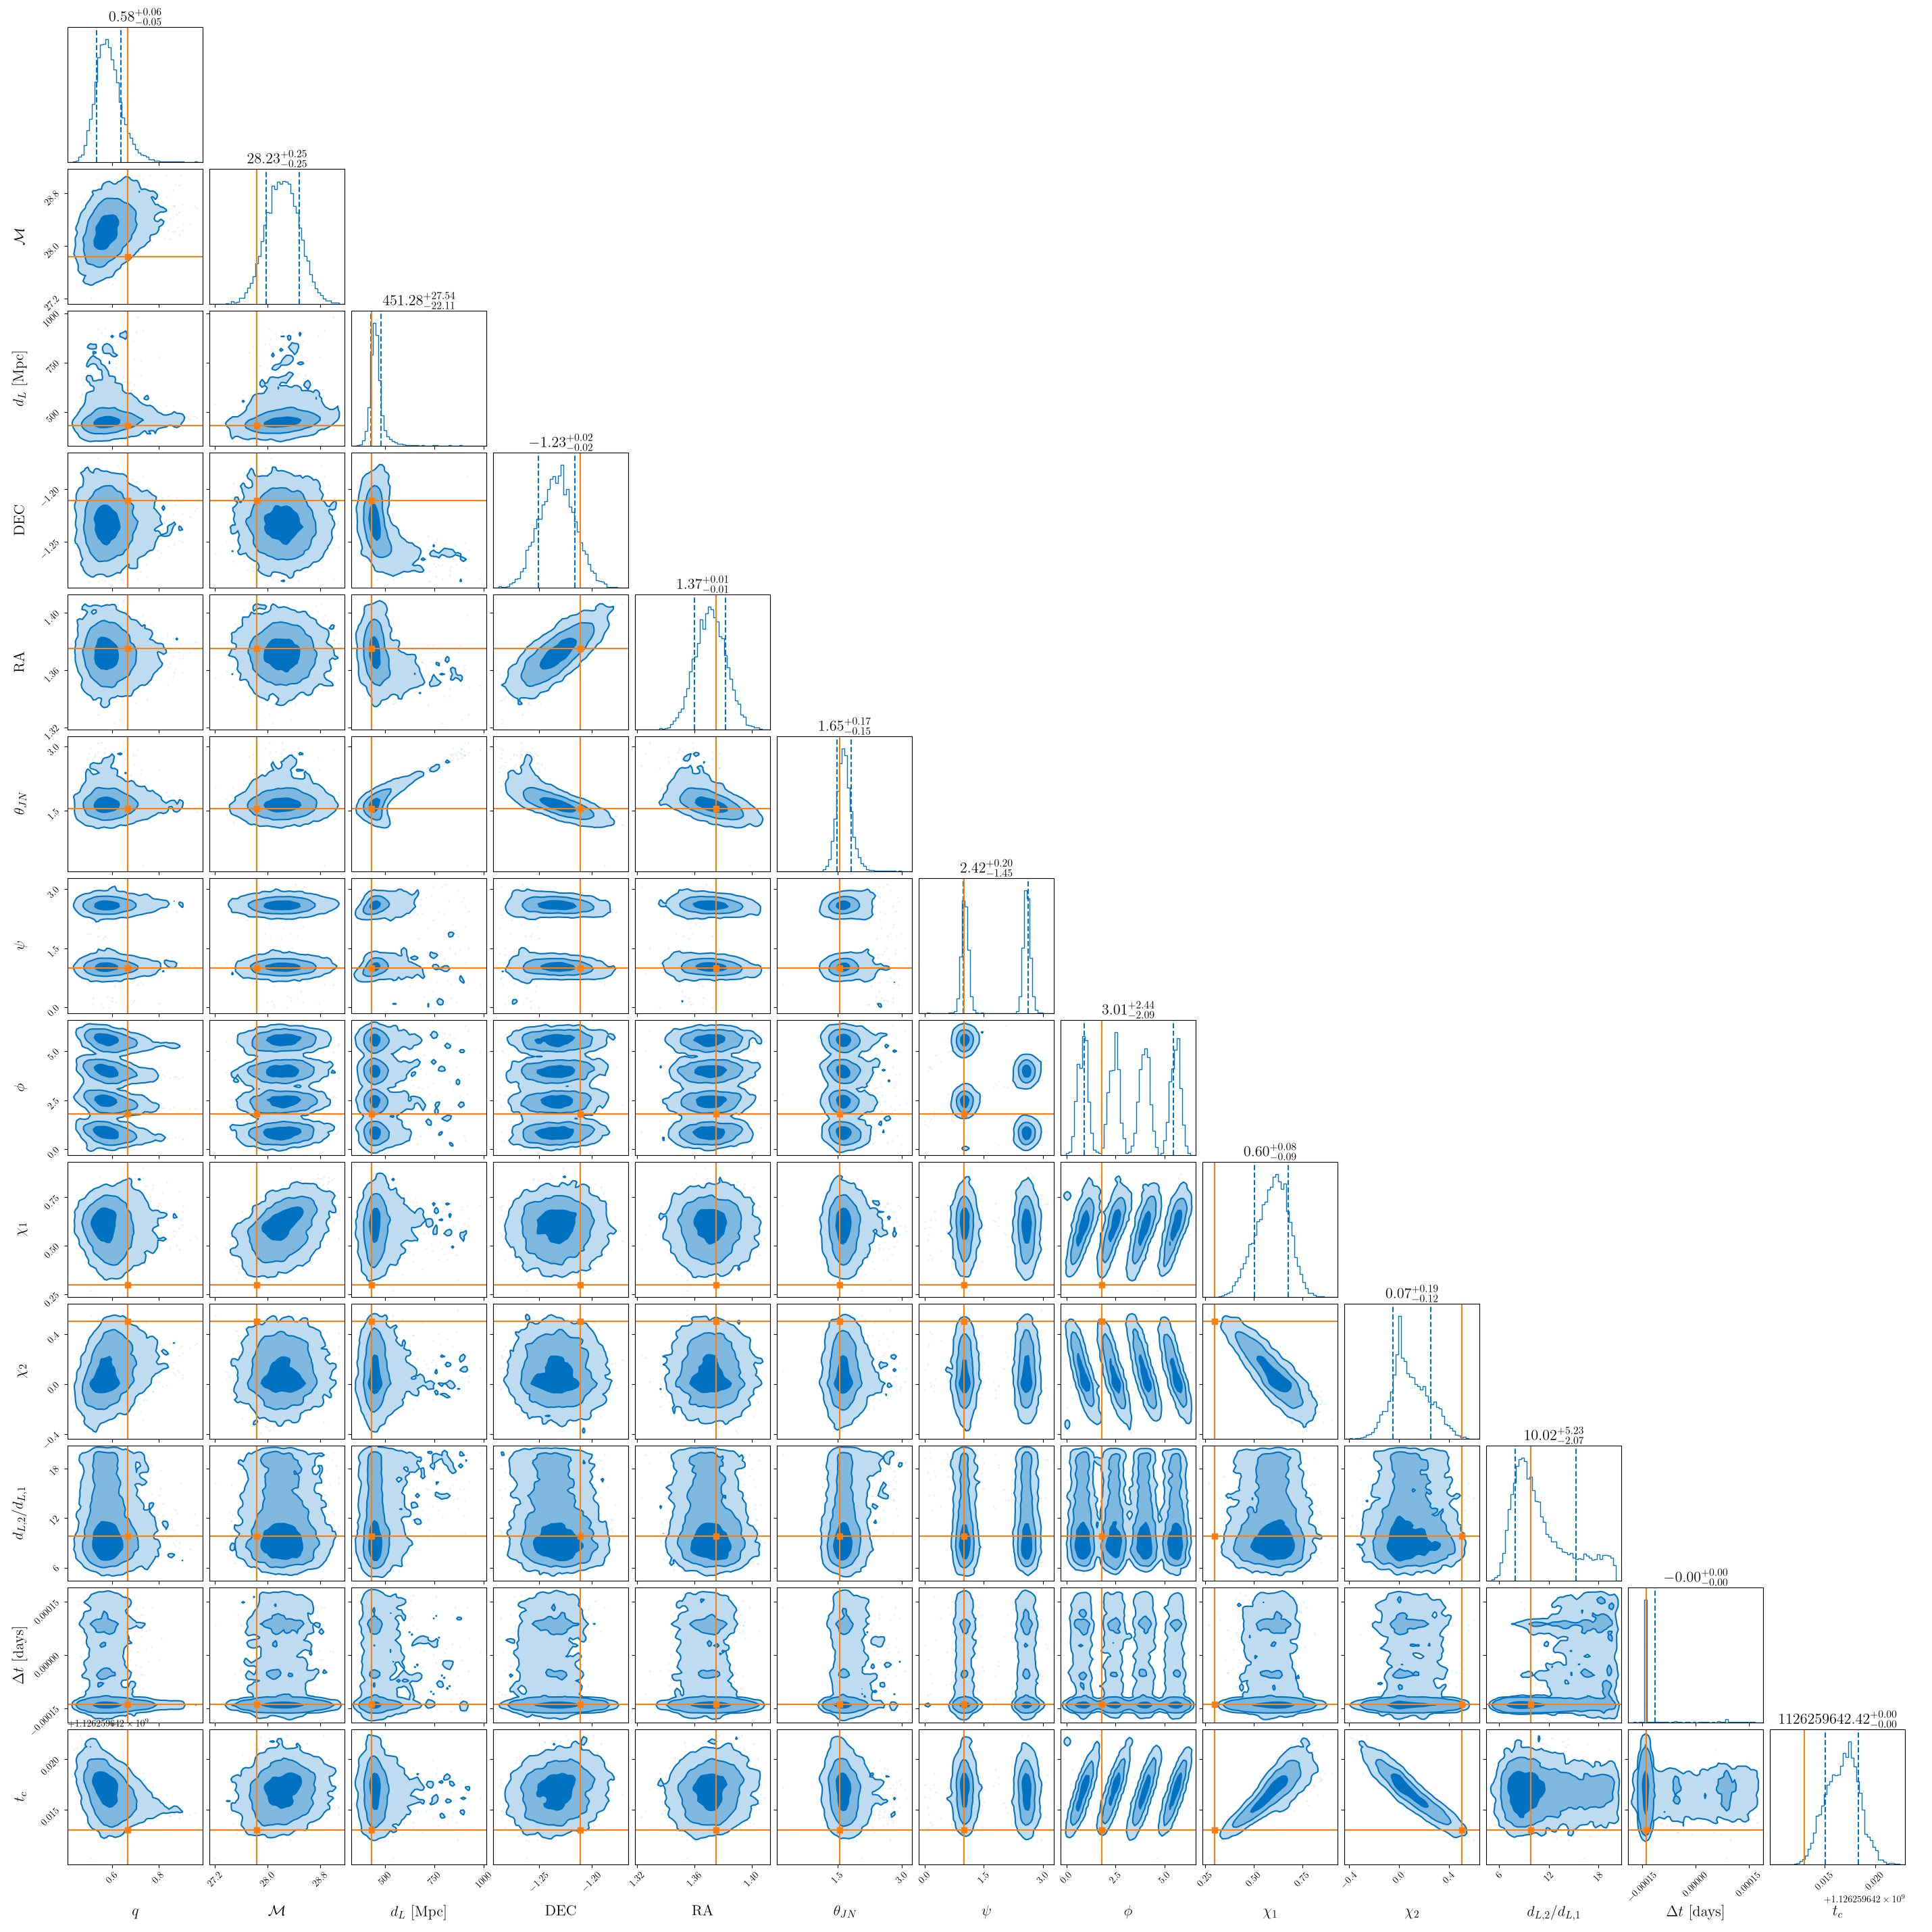

In [3]:
base = LENS / 'n1000_dz0.1_dur32'
show(base / 'n1000_dz0.1_dur32_agn_corner.png', 'AGN model (full PE)')
show(base / 'n1000_dz0.1_dur32_generic_corner.png', 'Generic model (full PE)')
show(base / 'n1000_dz0.1_dur32_simple_corner.png', 'Simple model (full PE)')


### Bayes factors

$$\ln\mathrm{BF}(\mathrm{model\,vs\,simple}) = \log Z_{\mathrm{model}} - \log Z_{\mathrm{simple}},\qquad \log_{10}\mathrm{BF} = \ln\mathrm{BF}/\ln 10.$$

Also recorded: $\ln\mathrm{BF}(\mathrm{signal\,vs\,noise}) = \log Z - \log Z_{\mathrm{noise}}$.

| Comparison | $\ln\mathrm{BF}$ | $\log_{10}\mathrm{BF}$ | BF | Reading |
|---|---:|---:|---:|---|
| AGN vs simple | 2.05 ± 0.4 | 0.89 | ≈ 8 | substantial, not strong |
| generic vs simple | 4.21 ± 0.4 | 1.83 | ≈ 68 | strong |
| generic vs AGN | ≈ 2.17 | ≈ 0.94 | ≈ 9 | favors generic |

All three detect the signal overwhelmingly ($\ln\mathrm{BF}(\mathrm{signal\,vs\,noise})$ ≈ 942–946).

### Interpretation

**AGN corner**

- Well recovered: $\mathcal{M}\approx 29.5$ (inj 30), $d_L\approx 486$ (500), sky, $\log_{10} M_{lz}\approx 5.05$ (5.0).
- Biased / weak: $R_{\rm orbit}\approx 78$ vs 50 (~2σ), $y_{\rm src}\approx 0.38$ vs 0.50; correlated with each other. With a faint second image they mainly set a weak beat pattern.
- **Spin / mass-ratio bias:** $q\approx 0.56$ vs 0.67, $\chi_1\approx 0.60$ vs 0.3, $\chi_2\approx 0.06$ vs 0.5 (anti-correlated). Present at maximum likelihood → not just prior volume.
- $t_c$ 4 ms late: degeneracy with wrong spins/Mc (waveform peak slides; geocent_time compensates).

**Generic corner**

- $\Delta t$ pinned to the injected delay (in these files still stored in days, so titles show −0.00, actuallyy −12 s).
- $d_{L,2}/d_{L,1}\approx 7.9$ (inj 9.8), broad as expected for a weak image 2.
- $\mathcal{M}_2/\mathcal{M}_1\approx 1.009$ vs 1.037; $\Delta\phi_{12}$ OK; Δι, Δψ mostly prior-like.
- Same CBC spin/q bias as AGN. Flexible image parameters fit the faint second image slightly better than the rigid AGN map, so higher evidence.

**Simple corner**

- Same $\Delta t$ spike, but a larger tail off the spike; lower peak likelihood.
- $d_{L,2}/d_{L,1}$ median ≈ 10 (truth 9.8), with a pile-up toward the prior edge.
- Loses because it cannot make the AGN image phase / mass shifts.

**Why generic can beat AGN on an AGN injection**

The second image is only ~10% as loud (SNR ~4). Extra generic freedom can fit noise there cheaper than the Occam cost of the AGN prior volume (especially wrap-aliases in $M_{lz}$). This is clearer in the fixed-binary disk runs below.


## 5. Disk (binary fixed) PE - with nlive=1000, $\Delta\ln Z$<0.1, duration=32s

CBC parameters pinned to the injection (converted image 1 for generic/simple). Only lensing parameters and $t_c$ free. Question: can disk parameters be recovered once the binary is known?


**AGN disk (binary fixed)**

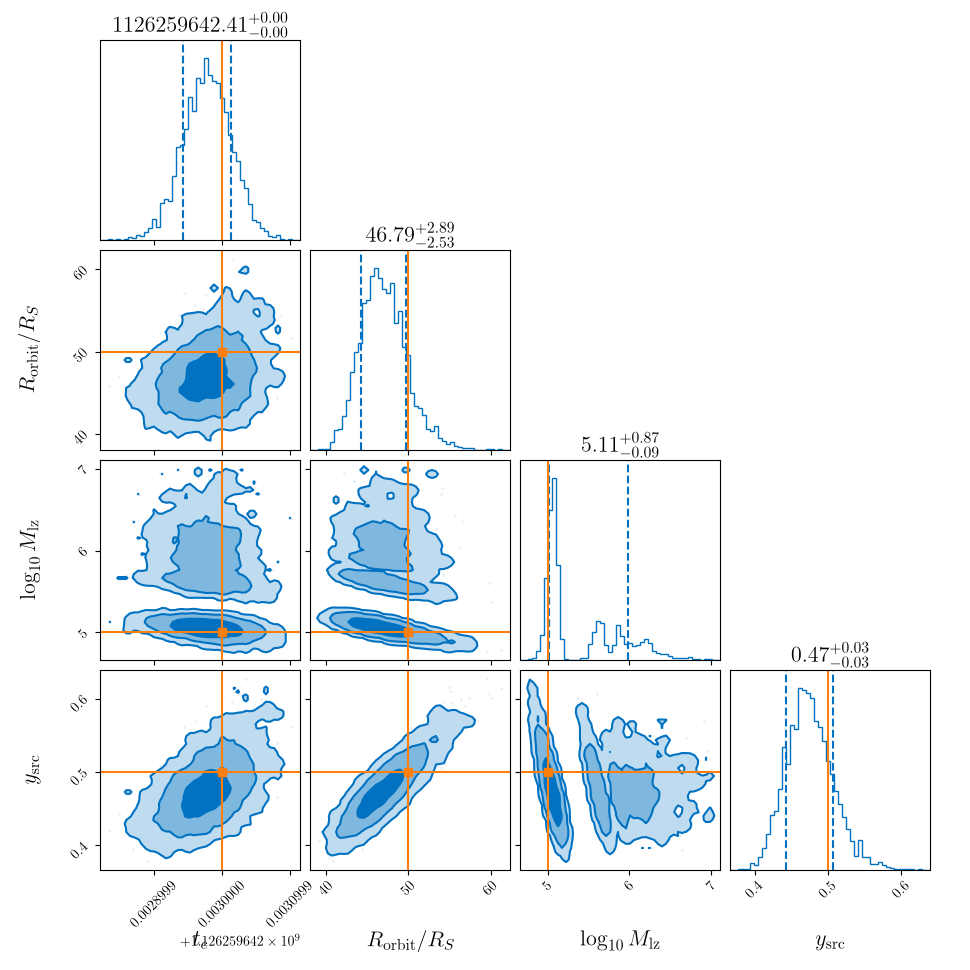

**Generic disk (binary fixed)**

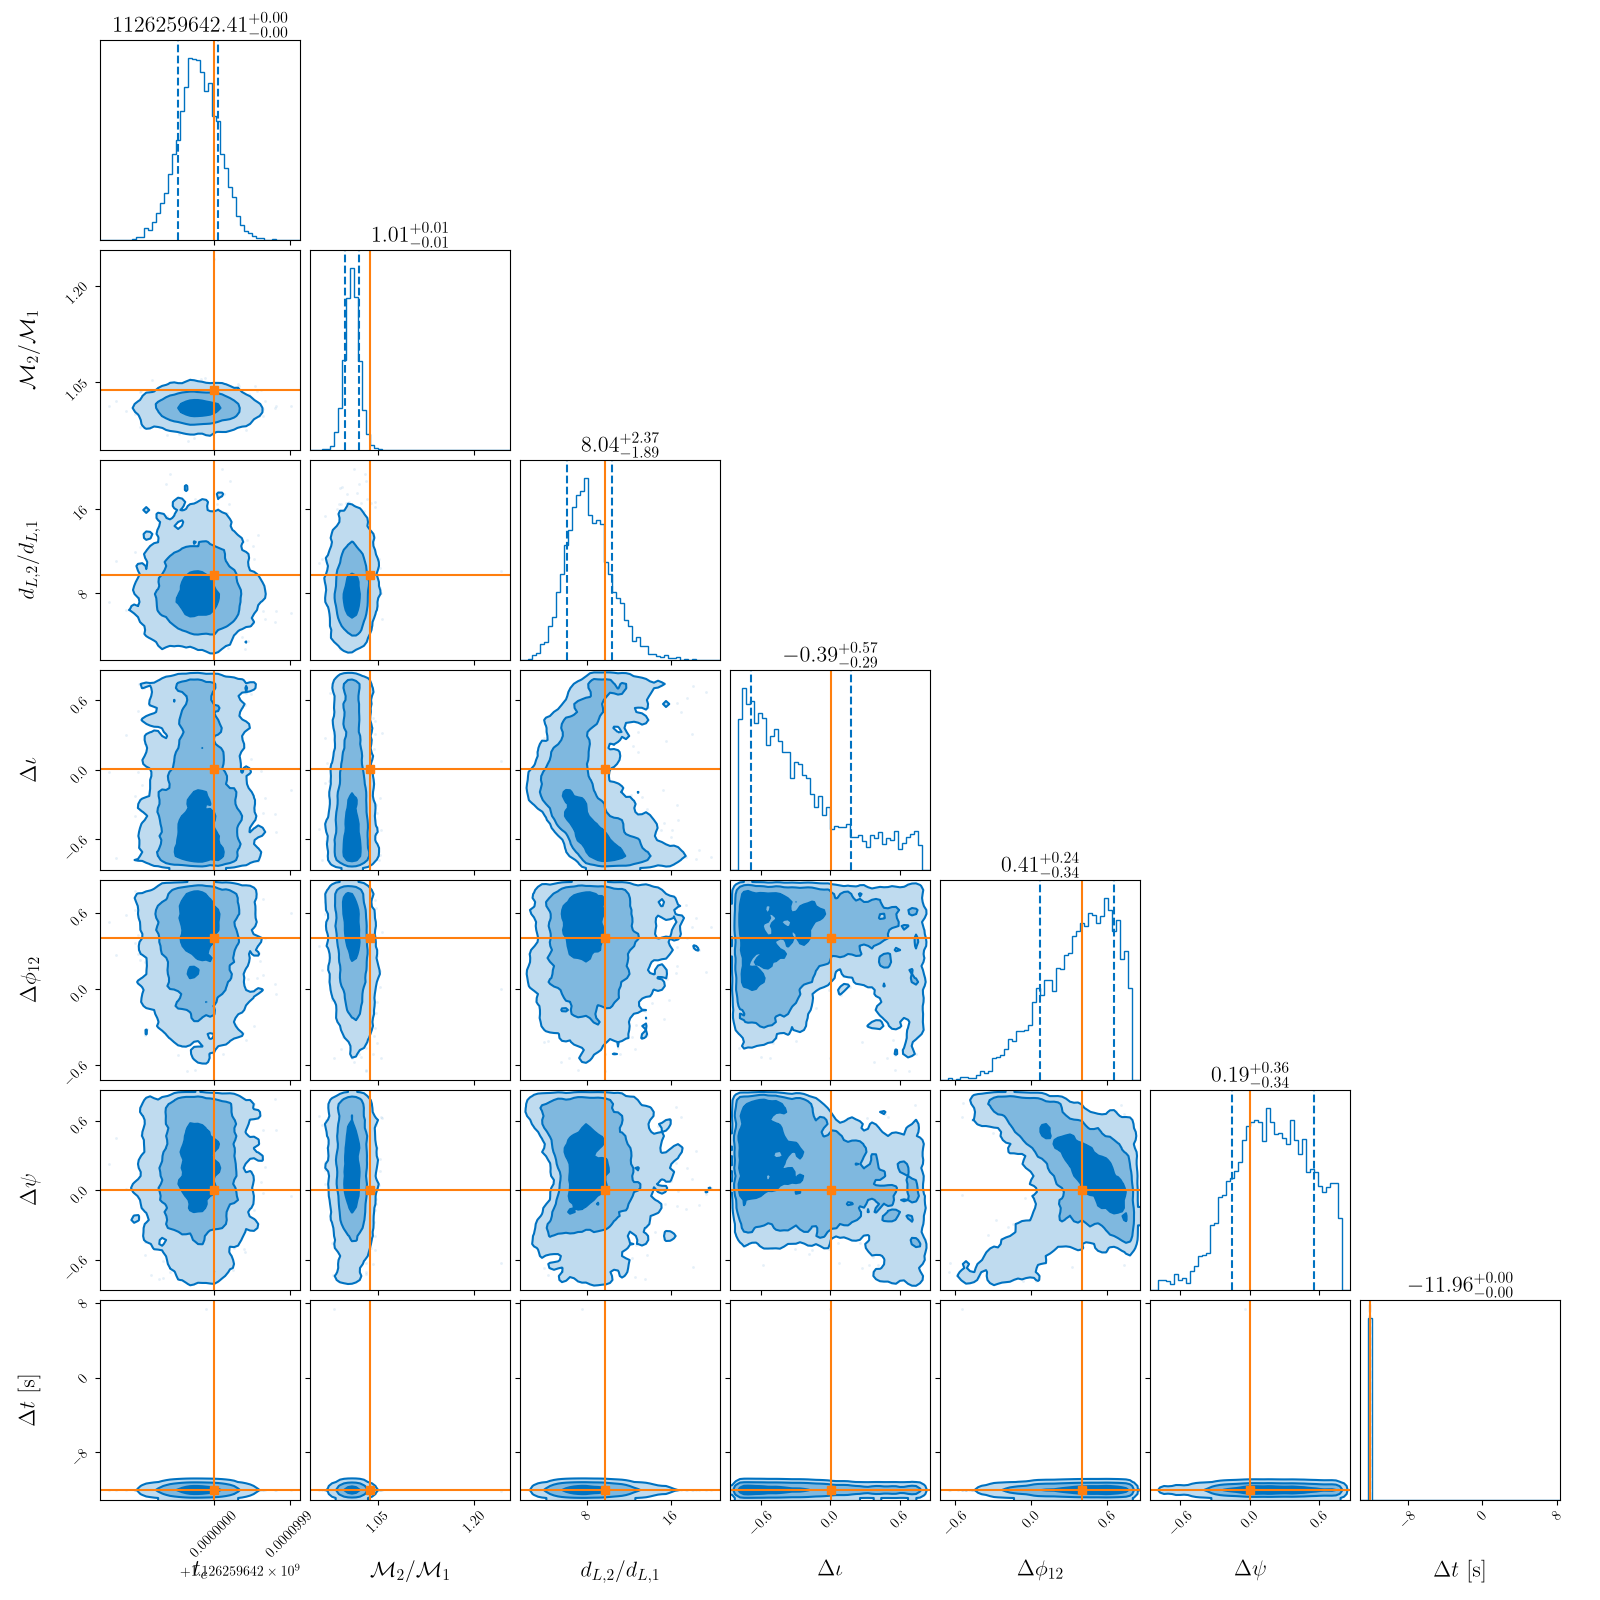

**Simple disk (binary fixed)**

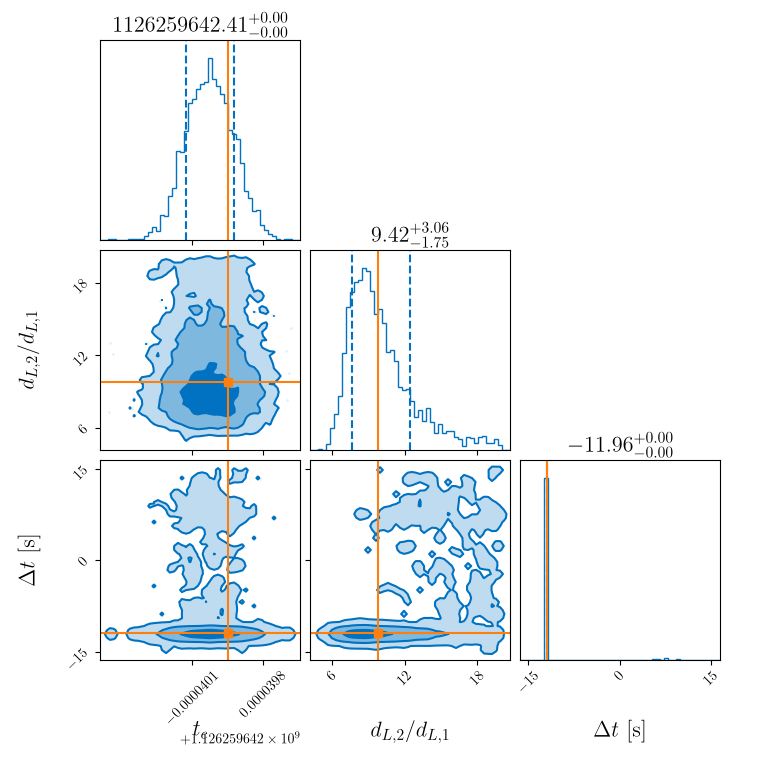

In [6]:
base = DISK / 'n1000_dz0.1_dur32'
show(base / 'n1000_dz0.1_dur32_agn_disk_corner.png', 'AGN disk (binary fixed)', width=700)
show(base / 'n1000_dz0.1_dur32_generic_disk_corner.png', 'Generic disk (binary fixed)', width=700)
show(base / 'n1000_dz0.1_dur32_simple_disk_corner.png', 'Simple disk (binary fixed)', width=700)


### Bayes factors (disk PE)


| Model | $\log Z$ | $\log_{10}\mathrm{BF}$ vs simple | Notes |
|---|---:|---:|---|
| Simple | −96499.91 | 0 | baseline |
| AGN | −96500.40 | **−0.21** | ties simple (Occam cancels likelihood gain) |
| Generic | −96495.11 | **+2.09** | wins; peak likelihood above a perfect match → noise fitting |


### Interpretation

- AGN **waveform** fit is fine (max log L saturates the matched-filter ceiling); high-likelihood samples near $(R,y,\log_{10}M)\approx(46,0.46,5.07)$.
- Evidence does not prefer AGN because the prior is much wider than the posterior, and **`log10_M_lz` is multimodal** (wrap aliases at 5.1, 6.0, …).
- Generic wins with wide Δι/Δψ priors by fitting image-2 noise. Need to shrink Δι, Δψ priors and perhaps reject AGN waveforms with `|Δt| > T/2`.

So: with the binary known, disk geometry is recoverable in the posterior, but model selection does not strongly favor the AGN parametrization on this faint-image injection, at least not until wrap aliases and generic prior width are handled.
